# Collaborative Filtering with Scikit-Surprise

* LLM Use:
    * LLMs for planning your code is not allowed. (For example -- don't use an LLM to solve part 1 "just to see how it's done" before doing it yourself.)
    * LLMs use for large-code writing is not allowed (I.E. multiple small lines, or single long lines of code)
    * LLMS use for low-level code-lookup and debugging support is allowed with clear attribtuion (For example, using an LLM to figure ou the best way to the the average of a dataframe in pandas is _fine_)
    * LLMs should not be used in the analysis part, except for spelling and grammar support. Your words should be your own.

## Goals:

By completing this project you should be able to:

 * Familiarize yourself with the scikit-surprise library for basic recommendation algorithm development and exploration.
 * Build up your computational programming skills (for those with less background in this type of coding)
 * Cement your understanding of Item--based nearest neighbor collaborative filtering algorithms by building them.
     * Note -- history with this project has taught me that a lot of people have a "concept" and "equation" level of understanding of Item-Item, but can't always translate this to correct code. Don't underestimate the amount of _reasoning_ that you'll practice in this step.
 * Get a chance to review some intermediate values from a recommendation algorithm.
 * Work with a (pretty basic) example content-filtering algorithm
 * Build familiarity with running and evaluating recommender systems

Note -- it's one thing to understand these algorithms at a concept level, but experiance shows that, until you've built them, there's always a bit of a gap between conept and practice. It might feel a bit tedious, but trust me that actually building some of these things is worthwhile.

## Overview

In this project you'll build some practical algorithms in the scikit-surprise (often just "surprise" in writing) python library. This is a popular recommendation algorithm library focusing on more traditional technologies and being easy to approach for simple exploration and experimentation.

Once we build a few algorithms we will use the surprise library's tools to run and analyze a basic evaluation.

## Outline

I've broken down this project into four parts

1.  A basic User-Item average algorithm.
2.  An Item-Item algorithm
3.  Content-Filtering
4.  A basic evaluation
5.  Our first experiment

## Notes:
* We will use a subset of the MovieLens dataset for this project. This will speed up the work drastically, but will definitely skew the results as our subsample is going to be much denser than a normal dataset.

To start this project, make a copy of this notebook: <https://colab.research.google.com/drive/1zK1_HQJ4HEkfxnaZPicdqGIAh2YJ8N-Y?usp=sharing>

by clicking File --> save a copy in Drive like below. Then please work on your copy.

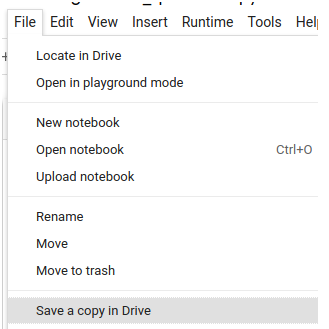

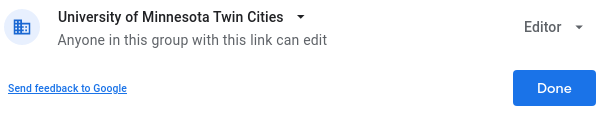


# References

Examples:
* (chatgpt) "How to lookup a value in column C, by indexing Column A and Column B in Pandas dataframe" - Gave me an answer to set index => df.set_index(["A", "B"])["C"] and use .loc[(a, b)] as a tuple value.

* (chatgpt) "How to add progress bar for training loops" : gave me the answer of using tqdm while iterating over loops, and references Session 9's notebook. This was to track the training as it takes so long to complete.

* (Chatgpt) "How to save the trained model in google drive and local machine after training such that it can be used later without training again" => gave a snippet of code to save in drive and upload when we need to use those models

* (chatgpt) - Had to learn quite a bit on using surprise algo - "What are internal and raw iids" , "why am I getting an error when I pass the iid" - understood on passing raw_iids as str.

* (chatgpt) - "I have a model trained and similarities stored in a dictionary inside the model using surprise, what are the methods available in surprise for me to access the values stored in the model' => gave me an answer on different methods such as n_items, ur, to_raw_iid, to-inner_iid, to_raw_uid, ir, n_itme, n_ratings, all_ratings etc. I used these to answer the questions

* (chatgpt) - "what is the best method of finding the movie name from the dataframe from raw-iids" => gave me an example os using loc and converting the iid to str and extracting the movie name from the dataframe that i used throughout

* (chatgpt) - "I have used a counter to get the count of items, how do i get the max count of it to find the most frequent item" => gave me an exmaple of using the max functions with key as ctr.get

* (chatgpt) - "What is the syntax to plot a graph in pandas from a dataframe. Tell me the paramaters I can use to plot a line graph with markers" => Gave me the plot function and syntax to pass parameters such as markere, title etc.


# please read
OK. So this one takes a little contextualization. This line of code installs the surprise library. It's a little out of date, but it still seems to be one of the best python libraries for quickly exploring the basics of recommendation that we could find.

The problem: It's not compatible with numpy version 2, and google collab upgraded to numpy version 2 a while ago. There are two fixes:

1. (What we did last year) You can manually force-downgrade numpy. If you do this **because numpy was already loaded by the python runtime you have to force restart the runtime** This is pretty error prone for a project, but it's robust.

2. (What I want to try this year) The original author of scikit surprise has an _unmerged_ branch of code which he claims upgrades everything to numpy2 compatiblity. The following line of code installs that specific version of the code.

**what does this mean for you** -- right now, we're using an _under-tested_ version of the surprise library. This might be a bit instable (which scares the heck out of me for project purposes) but it also _should_ be a lot easier to work with than option 1 (which wasted a lot of student time by being error-prone)

We've done some basic testing and haven't run into any errors, but that's no garuntee, so **please let me know if you're getting errors on slack**. I do have a drop-in replacement that is more ugly, but we can switch to if this doesn't work. Sorry I don't have a cleaner answer here -- but for the techniques we're learning -- this is the go-to-library.


In [1]:
!pip install git+https://github.com/NicolasHug/Surprise.git@fixnp2
# install surprise -- this takes a minute or so... we might not end up using this framework very much, but it's nice to have a _reall_ tookit


  Cloning https://github.com/NicolasHug/Surprise.git (to revision fixnp2) to /tmp/pip-req-build-hbojvbgy
  Running command git clone --filter=blob:none --quiet https://github.com/NicolasHug/Surprise.git /tmp/pip-req-build-hbojvbgy
  Running command git checkout -b fixnp2 --track origin/fixnp2
  Switched to a new branch 'fixnp2'
  Branch 'fixnp2' set up to track remote branch 'fixnp2' from 'origin'.
  Resolved https://github.com/NicolasHug/Surprise.git to commit 935a0ea7609ee10897c5d9c6de9ed18df5fdcd93
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2556284 sha256=e47be6f4d2297d29a140529990eefeda9bca1b00a053c4bc4522988f4969b858
  Stored in directory: /tmp/pip-ephem-wheel-cache-sxf1ir_h/wheels/68/ab/41/537c53abc220a1fb4a11000e7272d0478452b472e9f3a9359d
Successfully built scikit-surprise


In [2]:
# install surprise -- this takes a minute or so... we might not end up using this framework very much, but it's nice to have a _reall_ tookit
import random
import numpy as np
import pandas as pd

my_seed = 2025
random.seed(my_seed)
np.random.seed(my_seed)

In [3]:
# use surprise to download the ml-1m dataset (https://grouplens.org/datasets/movielens/1m/). Please input "Y" when being asked "Do you want to download it".
from surprise import Dataset

data = Dataset.load_builtin('ml-1m')

Dataset ml-1m could not be found. Do you want to download it? [Y/n] y
Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-1m.zip...
Done! Dataset ml-1m has been saved to /root/.surprise_data/ml-1m


In [4]:
# Pre-processing step -- filter down to the N most popular users and M most popular items. This will DEFINTIELY skew our end-results since these are the "easy" items and "easy" users to recommend for.
N_ITEMS = 1164
N_USERS = 1812
# These numbers were chosen to keep the ratio of items to users about the same.


# first filter to the popular items
ratings_df = pd.DataFrame(data.raw_ratings, columns=["userId", "movieId", "rating", "tstamp"])
rating_count_by_item = ratings_df.groupby("movieId")["rating"].count()
rating_count_by_item = rating_count_by_item.sort_values(ascending=False)
ITEMS = rating_count_by_item.index[:N_ITEMS]
ratings_df = ratings_df[ratings_df['movieId'].isin(ITEMS)]

# then filter to the active users
rating_count_by_user = ratings_df.groupby("userId")["rating"].count()
rating_count_by_user = rating_count_by_user.sort_values(ascending=False)
USERS = rating_count_by_user.index[:N_USERS]
ratings_df = ratings_df[ratings_df['userId'].isin(USERS)]

# Finally, convert to a matrix structure.
rating_matrix = ratings_df.pivot(index='userId', columns='movieId', values='rating')

# # just for sorting the rows/columns as they were alphabetical before
rating_matrix = rating_matrix.reindex(sorted(rating_matrix.index, key=int), axis=0)
rating_matrix = rating_matrix.reindex(sorted(rating_matrix.columns, key=int), axis=1)

# # user x movie
display(rating_matrix)

movieId,1,2,3,5,6,7,10,11,16,17,...,3873,3893,3897,3911,3916,3917,3927,3948,3949,3952
userId,,,,,,,,,,,,,,,,,,,,,
10,5.0,5.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN
15,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN
17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
18,4.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,4.0,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
19,5.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6025,5.0,NaN,3.0,NaN,NaN,4.0,NaN,4.0,NaN,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6035,4.0,NaN,1.0,1.0,NaN,3.0,NaN,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6036,NaN,NaN,NaN,NaN,3.0,NaN,NaN,3.0,3.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
import os

# Locate the movies.dat file using the path from the surprise dataset
ratings_file = data.ratings_file
movies_file = os.path.join(os.path.dirname(ratings_file), "movies.dat")

# Load the movies data
items = pd.read_csv(movies_file,
                    delimiter="::",
                    names=["movieId", "movieName", "genres"],
                    engine='python',
                    encoding="ISO-8859-1")

# Convert movieId to string to match the column names in rating_matrix
items['movieId'] = items['movieId'].astype(str)

# Filter to include only the N most popular items (ITEMS) defined in pre-processing
items = items[items['movieId'].isin(ITEMS)]
items = items.sort_values('movieId').reset_index(drop=True)

# Create the genre matrix
genre_matrix = items['genres'].str.get_dummies(sep='|')
# Set the index to be the movieId so we can align with ratings
genre_matrix.index = items['movieId']

display("items dataframe")
display(items.head())
display("genre_matrix dataframe")
display(genre_matrix.head())
# Note -- it's not clear in advance -- but the movieIds are _strings_ here.


'items dataframe'

,movieId,movieName,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,10,GoldenEye (1995),Action|Adventure|Thriller
2,1009,Escape to Witch Mountain (1975),Adventure|Children's|Fantasy
3,1012,Old Yeller (1957),Children's|Drama
4,1017,Swiss Family Robinson (1960),Adventure|Children's


'genre_matrix dataframe'

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieId,,,,,,,,,,,,,,,,,,
1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
10,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1009,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1012,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1017,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
# Last step -- you'll want to use the datasets "data" -- we need this to have the setup filter based on the earlier data.

data = Dataset.load_from_df(ratings_df[["userId", "movieId", "rating"]], data.reader)

## Some notes on working with Surprise Algorithms

* [General guide](https://surprise.readthedocs.io/en/stable/building_custom_algo.html) This page jumps right into "building algorithms" -- but you can click around the docs from here easily.
* [Important note on IDs](https://surprise.readthedocs.io/en/stable/FAQ.html#raw-inner-note) -- Very short version -- a lot of real-world datasets have real-world dataset problems, such as item- and user-ids that are spread out, or non-numeric (making them insuitable for indexing arrays and matrixes). As such surprise has two SERPATE domains for user- and item-ids "raw" (string-valued dataset) ids, and "internal" (sequential integer) ids. The internal ids are nicely lined up and perfect for indexing into arrays and matrixes.

To help get the ball rolling here are two examples which can serve as basis for the work you will do later. This included one prediction algorithm that always predict the global average rating, and another that always predicts sci-fi at 5 stars.


In [ ]:
# An example of how to work with our data and the surprise objects.
from surprise import AlgoBase

# Taken from surprise docs, udpated for a pandas conversion
# (not super-necissary -- the numpy version in the tutorial is probably faster)
# and to show off internal/raw id conversion
class GlobalAveragePredictor(AlgoBase):
    def __init__(self):

        # Always call base method before doing anything.
        AlgoBase.__init__(self)

    def fit(self, trainset):

        # Here again: call base method before doing anything.
        AlgoBase.fit(self, trainset)

        # also prepare a pandas dataframe for familiatiry
        # colums are (internal) user_id , (internal) item_id and rating value.
        self.ratings_df =  pd.DataFrame(self.trainset.all_ratings(), columns=['uid', 'iid', 'rating'])

        # Compute the average rating.
        self.the_mean = self.ratings_df['rating'].mean()

        return self

    def estimate(self, u, i):
        return self.the_mean


# A second example here. This one uses our genre data -- recommending all "sci-fi" at 5, and everything else at a configurable default.
class SciFiFan(AlgoBase):
    def __init__(self, default_pred): # values passed to the `__init__` function are thought of as meta-parameters.
        AlgoBase.__init__(self)
        self.default_pred = default_pred

    # We do not override fit here because we don't do anything special to train the model.

    def estimate(self, u, i):
        # NOTE u and i are internal ids
        if self.trainset.knows_item(i):
            ml_item_id = self.trainset.to_raw_iid(i) # This let's us convert internal item ids to raw item ids.
            if genre_matrix.loc[ml_item_id, 'Sci-Fi']:
              #https://surprise.readthedocs.io/en/stable/trainset.html#surprise.Trainset.rating_scale
              return self.trainset.rating_scale[1]
            else:
              return self.default_pred
        else: # unknown item
          return self.default_pred

In [ ]:
# And here's an example using built-in surprise evaluation code to see how these do.
# I should note -- there are better evaluations you can build in surprise than this.
# Example: https://surprise.readthedocs.io/en/stable/getting_started.html#use-cross-validation-iterators

# This example just does a basic 25% hold-out train-test split and uses RMSE to evaluate.

from surprise.model_selection import train_test_split
from surprise import accuracy

# sample random trainset (75% of ratings) and testset (25% of ratings)
trainset, testset = train_test_split(data, test_size=0.25)

# define algorithms
avg_algo = GlobalAveragePredictor()
fan_algo_2 = SciFiFan(2) # if not sci-fi predict at 2
fan_algo_0 = SciFiFan(0) # if not sci-fi predict at 0

results = []
avg_algo.fit(trainset)
results.append(("avg_aglo", accuracy.rmse(avg_algo.test(testset),verbose=False)))

fan_algo_2.fit(trainset)
results.append(("fan_algo_2", accuracy.rmse(fan_algo_2.test(testset),verbose=False)))

fan_algo_0.fit(trainset)
results.append(("fan_algo_0", accuracy.rmse(fan_algo_0.test(testset), verbose=False)))

results_df = pd.DataFrame(results, columns=("algorithm", "RMSE"))
display(results_df)
# As you might expect -- the sci-fi fan algorithm isn't actually very good for most users, so we have pretty big errors on average.


,algorithm,RMSE
0,avg_aglo,1.072593
1,fan_algo_2,1.963540
2,fan_algo_0,2.722569


# Algorithm 1: User-Item Average.

This algorithm is _barely_ a personalized algorithm -- while it does make different predictions for each user, it will ultimatley provide the same recommendation to every user. The prediction equation for this algorithm is as follows:

$\hat{r_{ui}} = \mu_i + \mu_u$

In otherwords -- to predict for user $u$ and item $i$ we add an item-score and a user-score. These two scores can be computed MANY ways, but the most common is a two-pass algorithm:

1. Given the list of training ratings...
2. compute the global average rating across all items and users
3. compute a damped item-average for each item. (damp the averages to the global mean) -- these values are $\mu_i$
4. substract the average item ratings from the observed ratings
5. With these modified ratings compute the user-average rating for each user (again damped, in this case damp the ratings towards 0) -- these are the $\mu_u$ values, They are an estimate of how much a user tends to rate above, or below, the average for the items they have rated.

Then when predicting we can:
1. look up the $mu_u$ and $mu_i$ values and compute $\hat{r_{ui}}$
2. If the user was not in our training dataset, we can use $\mu_u = 0$.
3. If the item was not in our training dataset, we can use $\mu_i = \mu_g$ (where $\mu_g$ is the global average rating)


In [7]:
from surprise import AlgoBase

class UserItemBaseline(AlgoBase):
    def __init__(self, damping_factor=5):
        AlgoBase.__init__(self)
        self.damping_factor = damping_factor

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)

        # 1. delete or reset storage for mu_g, mu_u and mu_i values
        # (algorithm objects are meant to be trained repeatedly, and should not carry data over)
        self.mu_g = None
        self.mu_u = None
        self.mu_i = None

        # set up any other data transformations you want -- for example, if you want a dataframe you can get code for that above.
        self.ratings_df =  pd.DataFrame(self.trainset.all_ratings(), columns=['uid', 'iid', 'rating'])

        # 2. compute mu_g -- the global average
        self.mu_g = self.ratings_df['rating'].mean()

        # 3. compute mu_i -- the damped item-averages
        item_rating_sum = self.ratings_df.groupby('iid')['rating'].sum()
        item_rating_count = self.ratings_df.groupby('iid')['rating'].count()
        self.mu_i = (item_rating_sum + self.damping_factor * self.mu_g) / (item_rating_count + self.damping_factor)

        # 4. compute mu_u -- the damped user-averages
        #    HINT -- this is easy if you subtract the item-average ratings from the ratings before computing averages.
        self.ratings_df = self.ratings_df.merge(self.mu_i.rename('mu_i'), left_on='iid', right_index=True)
        self.ratings_df['rating_adj'] = self.ratings_df['rating'] - self.ratings_df['mu_i']
        user_rating_sum = self.ratings_df.groupby('uid')['rating_adj'].sum()
        user_rating_count = self.ratings_df.groupby('uid')['rating_adj'].count()
        self.mu_u = (user_rating_sum) / (user_rating_count + self.damping_factor)

        # This function returns self.
        return self

    def estimate(self, u, i):
        # pull up mu_u and mu_i -- or if the items are not known to the training dataset -- fallback values
        mu_u = 0
        mu_i = self.mu_g

        if self.trainset.knows_user(u):
            mu_u = self.mu_u[u]
        if self.trainset.knows_item(i):
            mu_i = self.mu_i[i]

        return mu_u + mu_i


## Part 1 Questions


In [ ]:
# What would we predict for user 175 and item 1 using this baseline model.

from surprise.model_selection import train_test_split
from surprise import accuracy

baseline_algo = UserItemBaseline()
baseline_algo.fit(data.build_full_trainset())
print(baseline_algo.predict('175', '1'))

user: 175        item: 1          r_ui = None   est = 4.36   {'was_impossible': False}


In [ ]:
# Who are the users with the top-5 and bottom-5 values for mu_u? What are those values?

#(Hint -- the following code will train the model on all of the data -- you can then inspect the fit instance data.)
temp  = UserItemBaseline()
temp.fit(data.build_full_trainset())

top5 = temp.mu_u.sort_values(ascending=False).head(5)
bottom5 = temp.mu_u.sort_values(ascending=True).head(5)

print("Top-5 (raw uid, mu_u):")
for inner_uid, val in top5.items():
    print(temp.trainset.to_raw_uid(inner_uid), val)

print("\nBottom-5 (raw uid, mu_u):")
for inner_uid, val in bottom5.items():
    print(temp.trainset.to_raw_uid(inner_uid), val)


Top-5 (raw uid, mu_u):
4801 1.358446742869477
4086 1.1791376984779465
5862 1.124325704192145
372 1.1211331612473603
3032 0.9606959538268549

Bottom-5 (raw uid, mu_u):
5686 -1.4590894103324816
5039 -1.2437600263011086
5113 -1.163524802779451
1340 -1.1378582717893742
1912 -1.1255056100952399


In [ ]:
# What does a high or low value of mu_u mean about a user?

'''
ANS: This value represents how much the users ratings on average differ from the average rating of that item.
High value indicates that the user tends to rate higher than the average rating usually and maybe generous.
While lower ratings indicate that the user tends to rate lower than average.
'''

'\nANS: This value represents how much the users ratings on average differ from the average rating of that item. \nHigh value indicates that the user tends to rate higher than the average rating usually and maybe generous. \nWhile lower ratings indicate that the user tends to rate lower than average.\n'

# Algorithm 2: Item-Item Collaborative Filtering
For this part you should implement the Item-Item collaborative filtering algorithm. Because this algorithm often is deployed with a pre-computed and truncated similarity model, we'll do the same here.

The constructor takes parameters:

* `model_size` -- When training the algorithm, how many possible neighbors to keep for each item? (keep the top `model_size` most similar items when training the model)
* `neighborhood_size` -- How many neighbors to use when actually predicting.

## Train (fit function)
Given the ratings this should:

1. Compute the global average rating.
2. Compute user-average ratings for the next step (use a damped average with damping factor of 5.
3. compute the item-item similarity matrix using adjusted cosine similarity. $$S_{ik} = \frac{ \sum_{u \in U_i \cap U_k} (r_{ui}-\mu_u)(r_{uk}-\mu_u)}{\sqrt{\sum_{u \in U_i \cap U_k} (r_{ui}-\mu_u)^2} \sqrt{\sum_{u \in U_i \cap U_k} (r_{uk}-\mu_u)^2}}$$
4. create the "truncated model" for item-item. As a reminder we store this instead of a complete item-item similarty matrix. You can choose how best to store this, but it should contain only `model_size` most similar items for each item (as well as their similarity scores).
    * Side note -- do not include an item as it's own potential neghbor.
5. You may store any other data you may want in advance. For example, you may want to pre-compute sets or lists of which items each user has rated.

## Predict (estimate)
This takes an internal user_id and an internal item_id and:

1. Figures out which items in the truncated model the user has rated.
2. Compute the neighborhood of the items-to-predict (`newighborhood_size` most similar rated items)
3. Computes the prediction using the equation from class: $$\hat{r}_{ui} = \frac{\sum_{k \in I_u \cap N_i}S_{ik}r_{uk}}{\sum_{k \in I_u \cap N_i}|S_{ik}|}$$

## Some hints:

Efficient computation of the item-item similarit matrix is important -- but tricky. We've downsized the dataset so a less efficient loop-based solution will probably be _fast enough to not be terrible_. Try to begin by coding something you're positive (and can confirm) is correct -- then loop back and make it faster while keeping the "obviously correct" code around so you can confirm your results are the same.

Please do not use the surprise `compute_similarity` function. That kind of defeats the purpose of this exercise -- you can, however, see if there's any pre-made functions in pandas, sci-kit, or numpy which can solve this problem (possibly with some data pre- or post-processing on your part).

While we have a few "built-in" checks in the questions that follow -- you should be pro-actively checking your computed values here -- it'll be easy to miss bugs if you're not looking at these and checking them against your instincts.

If asked to predict an item or user not known to the dataset use the global average rating as a "fallback" prediction.


In [ ]:
from surprise import AlgoBase
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

class ItemItemCF(AlgoBase):
    def __init__(self, model_size = 100, neighborhood_size=5):
        AlgoBase.__init__(self)
        self.model_size = model_size
        self.neighborhood_size = neighborhood_size
        self.damping_factor = 5


    def fit(self, trainset):
        AlgoBase.fit(self, trainset)

        # 1. delete or reset all derived values
        self.mu_g = None
        self.mu_u = None
        self.sim_model = None

        # 2. set up any data transformatinos you want
        self.ratings_df =  pd.DataFrame(self.trainset.all_ratings(), columns=['uid', 'iid', 'rating'])

        self.mu_g = self.ratings_df['rating'].mean()
        user_rating_sum = self.ratings_df.groupby('uid')['rating'].sum()
        user_rating_count = self.ratings_df.groupby('uid')['rating'].count()
        self.mu_u = (user_rating_sum + self.damping_factor * self.mu_g) / (user_rating_count + self.damping_factor)

        self.ratings_df = self.ratings_df.merge(self.mu_u.rename("mu_u"), left_on='uid', right_index=True, how='left')  # autocompleted code after self.mu was typed
        self.ratings_df['rating_adj'] = self.ratings_df['rating'] - self.ratings_df['mu_u']  # autocomplete code

        # 3. Compute the similarity matrix
        items = sorted(self.ratings_df['iid'].unique())
        item_users = self.ratings_df.groupby("iid")["uid"].apply(set).to_dict()

        # Creating index for using with .loc for adjusted ratings
        rating_adj_lookup_index = self.ratings_df.set_index(["iid", "uid"])["rating_adj"]

        sim_model = {}

        # Add tqdm to the outer loop for a progress bar
        for i in tqdm(items, desc="Computing Item Similarities"):
            sim_scores = []
            users_i = item_users[i]

            for k in items:
                # skip itself as neighbor
                if k == i:
                    continue

                common_users = users_i.intersection(item_users[k])
                if not common_users:
                    continue

                adj_rating_i = np.array([rating_adj_lookup_index.loc[(i, u)] for u in common_users])
                adj_rating_k = np.array([rating_adj_lookup_index.loc[(k, u)] for u in common_users])

                numerator = np.dot(adj_rating_i, adj_rating_k)
                denominator = np.sqrt(np.dot(adj_rating_i, adj_rating_i)) * np.sqrt(np.dot(adj_rating_k, adj_rating_k))

                if denominator == 0:
                    continue

                sim_scores.append((k, numerator/denominator))

        # 4. truncate the similarity model and store
            sim_scores.sort(key=lambda x: x[1], reverse=True)
            sim_model[i] = sim_scores[:self.model_size]

        self.sim_model = sim_model

        # 5. Any further pre-computation any you want to do should happen here.

        # This function returns self.
        return self

    def estimate(self, u, i):

      if (not self.trainset.knows_user(u)) or (not self.trainset.knows_item(i)):
          return self.mu_g

        # 1. compute the neighborhood for this prediction
      user_ratings = dict(self.trainset.ur[u])
      neighbors = self.sim_model.get(i, [])

      usable = [(k, sim) for (k, sim) in neighbors if k in user_ratings]
      if not usable:
          return self.mu_g

      usable.sort(key=lambda x: abs(x[1]), reverse=True)
      usable = usable[: self.neighborhood_size]

      # 2. predict
      num = 0.0
      den = 0.0
      for k, sim in usable:
          num += sim * user_ratings[k]
          den += abs(sim)

      if den == 0:
          return self.mu_g

      return num / den

        # return 0

## Part 2 Questions
Again -- we're using these questions both as a way to encourage you to check intermediary results for seeming _reasonable_ and a quick way for us to check if your results match those produced by any common solutions.


In [ ]:
# Train an item-item model on all ratings in the dataset as seen above, use this data for the following questions
item_item = ItemItemCF()
trainset = data.build_full_trainset()
item_item.fit(trainset)


Computing Item Similarities:   0%|          | 0/1164 [00:00<?, ?it/s]

In [ ]:
# save locally
import pickle
model_filename = "item_item_cf.pkl"

with open(model_filename, "wb") as f:
    pickle.dump(item_item, f)

# download to laptop

from google.colab import files
files.download(model_filename)

In [ ]:
# from google.colab import drive
drive.mount("/content/drive")

import os, pickle

# download to drive

folder = "/content/drive/MyDrive/RecSys_Models"
os.makedirs(folder, exist_ok=True)

model_path = os.path.join(folder, "item_item_cf.pkl")

with open(model_path, "wb") as f:
    pickle.dump(item_item, f)

print("Saved model to:", model_path)


In [ ]:
# # upload from drive and use it

from google.colab import drive
drive.mount("/content/drive")

import pickle

model_path = "/content/drive/MyDrive/RecSys_Models/item_item_cf.pkl"

with open(model_path, "rb") as f:
    item_item = pickle.load(f)

# test
print(item_item.predict("195", "1").est)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
4.292676607213804


In [ ]:
# What are the 20 most similar items to "Dracula: Dead and Loving It" (movieId 12) and what are their similarity scores?

# change to movie id 10

inner_iid = trainset.to_inner_iid("10")

top20_neighbors = item_item.sim_model[inner_iid][:20]
top20_raw = [(trainset.to_raw_iid(iid), sim) for (iid, sim) in top20_neighbors]

for rid, sim in top20_raw:
    movie_name = items.loc[items["movieId"].astype(str) == rid, "movieName"].values[0]
    print(f"{sim:.4f}  {movie_name}")


0.5867  Tomorrow Never Dies (1997)
0.5193  World Is Not Enough, The (1999)
0.4920  Man with the Golden Gun, The (1974)
0.4437  For Your Eyes Only (1981)
0.4132  Thunderball (1965)
0.4101  Spy Who Loved Me, The (1977)
0.4041  Live and Let Die (1973)
0.3575  Frighteners, The (1996)
0.3463  Dr. No (1962)
0.3436  Ninth Gate, The (2000)
0.3429  Licence to Kill (1989)
0.3422  On Her Majesty's Secret Service (1969)
0.3395  From Russia with Love (1963)
0.3325  View to a Kill, A (1985)
0.3106  Moonraker (1979)
0.2880  Deuce Bigalow: Male Gigolo (1999)
0.2852  Heartbreak Ridge (1986)
0.2795  Lethal Weapon 2 (1989)
0.2727  Supercop (1992)
0.2701  Kelly's Heroes (1970)


In [ ]:
# What does Item-Item predict for user 195 and movieId 1 (toy story)
pred = item_item.predict("195", "1")
print(pred)

user: 195        item: 1          r_ui = None   est = 4.29   {'was_impossible': False}


In [ ]:
# What are user 195's top-10 highest predicted items (excluding those they have rated already)

raw_uid = "195"
inner_uid = trainset.to_inner_uid(raw_uid)

rated_inner_iids = {iid for (iid, r) in trainset.ur[inner_uid]}
# findinf items rated

preds = []
for inner_iid in range(trainset.n_items):
    if inner_iid in rated_inner_iids:
        # skip rated items
        continue

    # predict for the remaining items
    raw_iid = trainset.to_raw_iid(inner_iid)
    est = item_item.predict(raw_uid, raw_iid).est
    preds.append((raw_iid, est))

# sort
preds.sort(key=lambda x: x[1], reverse=True)
top10 = preds[:10]

for raw_iid, est in top10:
    movie_name = items.loc[items["movieId"].astype(str) == raw_iid, "movieName"].values[0]
    print(f"{est:.4f}  {movie_name}")


5.0000  Better Off Dead... (1985)
5.0000  Pinocchio (1940)
5.0000  Mister Roberts (1955)
5.0000  Gandhi (1982)
5.0000  Gone with the Wind (1939)
5.0000  Mary Poppins (1964)
5.0000  It's a Wonderful Life (1946)
5.0000  Ordinary People (1980)
5.0000  Dead Again (1991)
5.0000  Birds, The (1963)


In [ ]:
# Which item (by name please) appears the most in the truncated model?

from collections import Counter

ctr = Counter()

for i_inner, neigh_list in item_item.sim_model.items():
    for (k_inner, sim) in neigh_list:
        ctr[k_inner] += 1

most_inner_iid = max(ctr, key=ctr.get)
count = ctr[most_inner_iid]

most_raw_iid = trainset.to_raw_iid(most_inner_iid)

items["movieId"] = items["movieId"].astype(str)
movie_name = items.loc[items["movieId"] == most_raw_iid, "movieName"].values[0]

print(f"movieId: {most_raw_iid}, name: {movie_name}, count: {count}")

movieId: 3593, name: Battlefield Earth (2000), count: 394


# Algorithm 3 Content Filtering
For this part we'll implement a basic content-based personalized recommenders. These will be based off the movie genres.

We will implement a basic approach simple-count based approach. This is not particularly elegant, but it gives us something meaningful to compare item-item against.

## Computing Item Models.

We will be modeling the item data directly with the genre matrix. This is pre-computed in the provided data loading part of this notebook. To summarize though, each movie will be represented with an item-model: $$\theta_i = \left< g_{i,\textrm{Action}}, g_{i,\textrm{Adventure}}, \ldots, g_{i,\textrm{War}}, g_{i,\textrm{Western}}\right> $$Where $\theta_i$ is the item model and each $g_{i,\textrm{genre}}$ is 1 if item $i$ has the given genre, and 0 if it does not.

In the provided code we compute this as a pandas dataframe -- you can see an example of how to quickly access it in the example algorithms -- note that it is indexed by the movie id (which would be the external id in surprise, not the raw id)

## Computing user models.

This is done in the fit function. Make sure you use the passed in rating data -- not the rating matrix from earlier in this notebook. (You may find it useful to re-use that code to make a rating matrix for the passed in rating data) If you use "all" rating data, instead of the passed in rating data, your algorithm would technically be "cheating" in it's later evaluation.

For this algorithm, the user model is: $$\theta_u = \left< g_{u,\textrm{Action}}, g_{u,\textrm{Adventure}}, \ldots, g_{u,\textrm{War}}, g_{u,\textrm{Western}}\right> $$Where $\theta_u$ is the user model and each $g_{u,\textrm{genre}}$ is a count of how many movies in that genre user $u$ liked, minus how many they disliked. (Where we say a user "liked" a movie if they rated it 4 or greater, otherwise they disliked it).

You are free to compute this how you will, but here's a rough outline of how Kluver might approach this problem (to get you started):

1. Convert the provided training set into a rating dataframe
2. convert the rating values so that it has the value +1 where $r_{ui} \geq 4$ and -1 where $r_{ui} < 4$
3. Join this data frame against the genres matrix so that you know the genres for each rating.
4. Finally you need to summarize this into the genres. One way to do this would be per-genre:
    * First filter ratings to only those with a given genre (say, "Action")
    * Then do a per-user sum over this -- that will be the $g_{u,\textrm{Action}}$ values for each user.
    * Repeat this for each genre and merge the results together to form a $theta_u$ matrix.

## estimate
Finally, to predict you can simply take the dot product of $\tehta_u$ and $\theta_i$. This will give you a numeric value that, in principal, should be positive for movies the user will like, and negative for those they will not like.

A few notes here:

1. Your item genre matrix is likely indexed by external "raw" ids, not internal ids -- make sure you account for this.
2. The `TrainSet` class's keeps track of which items and users it's seen -- if it isn't aware of an item it will refuse to map to the raw id -- as such you will likely need a fallback for "unknown" users and "unknown" items -- in these cases please return the 0.


In [ ]:
from surprise import AlgoBase
import numpy as np
import pandas as pd


class SimpleGenre(AlgoBase):
    def __init__(self):
        AlgoBase.__init__(self)


    def fit(self, trainset):
        AlgoBase.fit(self, trainset)

        ratings_df = pd.DataFrame(self.trainset.all_ratings(), columns=["uid", "iid", "rating"])
        ratings_df["like"] = np.where(ratings_df["rating"] >= 4, 1, -1)  # autocompleted code line

        # create new column to merge genres with ratings df
        ratings_df["movieId"] = ratings_df["iid"].apply(self.trainset.to_raw_iid).astype(str)
        df = ratings_df.merge(genre_matrix, left_on="movieId", right_index=True, how="left")

        self.genre_cols = []
        for col in genre_matrix.columns:
            self.genre_cols.append(col)

        df[self.genre_cols] = df[self.genre_cols].fillna(0)  # Auto completed code
        df[self.genre_cols] = df[self.genre_cols].mul(df["like"], axis=0)

        self.theta_u = df.groupby("uid")[self.genre_cols].sum()

        # This function returns self.
        return self

    def estimate(self, u, i):
        if (not self.trainset.knows_user(u)) or (not self.trainset.knows_item(i)):
            return 0

        raw_iid = str(self.trainset.to_raw_iid(i))
        theta_i = genre_matrix.loc[raw_iid, self.genre_cols].to_numpy(dtype=float)
        theta_u = self.theta_u.loc[u, self.genre_cols].to_numpy(dtype=float)

        return float(np.dot(theta_u, theta_i))
        # return 0


## Algorithm 3 Questions


In [ ]:
# As before -- please create a version of your algorithm that's trained on all items and answer the following questions
sg = SimpleGenre()
trainset = data.build_full_trainset()
sg.fit(trainset)

In [ ]:
# What is the item-model for Jurassic Park (Movie 480)
movie_id = "480"
print(genre_matrix.loc[movie_id])

Action         1
Adventure      1
Animation      0
Children's     0
Comedy         0
Crime          0
Documentary    0
Drama          0
Fantasy        0
Film-Noir      0
Horror         0
Musical        0
Mystery        0
Romance        0
Sci-Fi         1
Thriller       0
War            0
Western        0
Name: 480, dtype: int64


In [ ]:
# What is the user-model for user 195? (Note -- don't be afraid to go pull the actual user-rating out and check your math here)
inner_uid = trainset.to_inner_uid("195")
print(sg.theta_u.loc[inner_uid])

Action          21
Adventure       17
Animation       11
Children's       9
Comedy          57
Crime           33
Documentary      2
Drama          129
Fantasy         10
Film-Noir       10
Horror          16
Musical          3
Mystery         14
Romance         18
Sci-Fi           6
Thriller        29
War             22
Western          4
Name: 48, dtype: int64


In [ ]:
# math verification

inner_uid = trainset.to_inner_uid("195")
ratings = trainset.ur[inner_uid]

for iid, rating in ratings:
    raw_iid = trainset.to_raw_iid(iid)

    # filter for the genre
    if genre_matrix.loc[raw_iid, "Western"] == 1:
        movie_name = items.loc[items["movieId"].astype(str) == raw_iid, "movieName"].values[0]
        like_status = "+1" if rating >= 4 else "-1"
        print(f"{like_status}    {rating}    {movie_name}")


+1    5.0    Unforgiven (1992)
+1    5.0    Dances with Wolves (1990)
+1    4.0    Young Guns (1988)
+1    4.0    Three Amigos! (1986)
-1    3.0    Wild Wild West (1999)
+1    4.0    Maverick (1994)
+1    5.0    Good, The Bad and The Ugly, The (1966)
-1    3.0    Back to the Future Part III (1990)


In [ ]:
# How often does this algorithm (the version fit on all data) accurately estimate if a user liked/disliked a movie?
# (hint -- the AlgoBase class has quite a few ways to get predictions out.
#          If you want to use the esitmate function directly you'll have to
#          capture the trainingset so you can convert to the internal ids.
#          Otherwise -- you can use the predict function (https://surprise.readthedocs.io/en/stable/algobase.html#surprise.prediction_algorithms.algo_base.AlgoBase.predict)
#          or the test function -- but you'll have to do more work processing
#          the output objects as these are not raw numbers.


testset = trainset.build_testset()
preds = sg.test(testset)

pred_df = pd.DataFrame(
    [(p.uid, p.iid, p.r_ui, p.est) for p in preds],
    columns=["uid", "iid", "true_rating", "est"]
)

pred_df["true_like"] = pred_df["true_rating"] >= 4
pred_df["pred_like"] = pred_df["est"] >= 0

accuracy = (pred_df["true_like"] == pred_df["pred_like"]).mean()
print("Accuracy", accuracy)



Accuracy 0.5890561696593808


# Part 4 -- A basic evaluation

For this part we are going to perform a basic evaluation. Our protocol will be very simple, but more than enough for our needs right now.

1. create a random 20% hold out train-test split (that is to say, put 20% of the ratings in the test set, keep 80% for training.
2. Train all of the algorithms in this notebook with the one training set.

    * global average (provided)
    * sci-fi fan (provided)
    * user-item baseline
    * item-item
    * genre filtering.

   For all of the above, use their default parameters if they have parameters (for example, use the default model size in Item-Item)
3. Compute the RMSE metric for each algorithm using the test set ratings.
4. Provide a sumary table/data-frame with one row per item.

You can see code above, or https://surprise.readthedocs.io/en/stable/getting_started.html#train-test-split-example for examples of how to do a simple evaluation like this in surprise.


In [ ]:
# TODO -- put code for eval here.
import pandas as pd
from surprise.model_selection import train_test_split
from surprise import accuracy

trainset, testset = train_test_split(data, test_size=0.20)

algos = [
    ("global_avg", GlobalAveragePredictor()),
    ("sci_fi_fan", SciFiFan(2)),
    ("user_item_baseline", UserItemBaseline()),
    ("item_item", ItemItemCF()),
    ("genre_filter", SimpleGenre())
]

results = []

for name, algo in algos:
    algo.fit(trainset)
    preds = algo.test(testset)
    rmse = accuracy.rmse(preds)
    results.append((name, rmse))

results_df = pd.DataFrame(results, columns=["Algorithm", "RMSE"])
print(results_df)


RMSE: 1.0715
RMSE: 1.9658
RMSE: 0.8844


Computing Item Similarities:   0%|          | 0/1164 [00:00<?, ?it/s]

RMSE: 0.9327
RMSE: 1.8453
            Algorithm      RMSE
0          global_avg  1.071524
1          sci_fi_fan  1.965812
2  user_item_baseline  0.884372
3           item_item  0.932749
4        genre_filter  1.845344


In [ ]:
# According to this evaluation, what algorithm performs the best and why?

'''
ANS:

User item baseline performs the best, as it has the lowest RMSE Error.
It may perform better as we are adjusting the ratings for each user and removing the bias.

'''

In [ ]:
# Would trust this evaluation if you were building a real system, and why?
'''
Ans:

RMSE would be a useful evaluation metric, but would not trust it completely.
This is because the train and test set split was random and may not represent the real world correctly,
we might have to do multiple iterations, such that the model trains on each rating atleast once.
'''

In [ ]:
# You Genre filter algorithm (presumably) performed quite poorly.
# Why did this happen?
# Do you think this is an accurate estimate of how well the genre filter would act as a recommender (picking items)

'''
Ans:
The genre filter performs poorly because that algorithm does not return a prediction of the rating of the movie.
It instead predicts how much the user would like that movie on a different scale, and can be negative as well indicating dislike.
Comparing ratings which is on a scale of 1 to 5 with like/dislike will perform bad and hence not accurate.
A better accurate evaluation metric would be precision, recall, F1-score etc.
'''

# Part 5 -- our first experiment.

It may surprise you to find out that we _actually do_ use the user-item baseline in MovieLens. We rarely use it directly, but instead we often subtract it from all ratings (which can act like a pre-normalization step making later algorithms easier to code, and generally perform better)

Because we use this as a key part of many other algorithms we have a specific interest in what the idea value of the damping factor should be. (This is also nice since it's probably the fastest algorithm so you won't spend forever on this task)

For this Part -- please devise an evaluation protocol (It's OK if you just use the same one from part 4 -- but I want you to have freedom to use other protocols if you want) and then test versions of the user-item baseline algorithmm with a range of damping values --What is the best damping value?


##Question -- What is your Evaluation Protocol?

RMSE and CV
The evaluation uses five-fold cross-validation with shuffling and a fixed random seed of 2025. The data is divided into five equal parts. In each iteration, four parts are used to train the model and the remaining part is used for testing, and this process repeats until each part has served as the test set once. For each damping value, the model is trained and evaluated across all folds. The prediction error is measured using RMSE, and the RMSE values from the five folds are averaged to obtain the final performance for that damping value. The damping value with the lowest average RMSE is selected as the best setting.


In [9]:
import numpy as np
import pandas as pd
from surprise.model_selection import KFold
from surprise import accuracy

damping_values = [0, 5, 10, 20, 50, 100, 500, 1000]

kf = KFold(n_splits=5, random_state=2025, shuffle=True)

results = []

for lambda_val in damping_values:
    fold_rmses = []

    for trainset, testset in kf.split(data):
        algo = UserItemBaseline(damping_factor=lambda_val)

        algo.fit(trainset)
        preds = algo.test(testset)
        rmse = accuracy.rmse(preds, verbose=False)
        fold_rmses.append(rmse)

    results.append({
        "damping_factor": lambda_val,
        "rmse_mean": np.mean(fold_rmses),
        "rmse_std": np.std(fold_rmses)
    })

rmse_df = pd.DataFrame(results).sort_values("rmse_mean").reset_index(drop=True)

display(rmse_df)

print(f"Best damping_factor = {rmse_df.iloc[0]['damping_factor']}")

,damping_factor,rmse_mean,rmse_std
0,0,0.885681,0.000769
1,5,0.885718,0.000791
2,10,0.885877,0.000814
3,20,0.886504,0.000860
4,50,0.890030,0.000994
5,100,0.898380,0.001177
6,500,0.955408,0.001751
7,1000,0.990132,0.001918


Best damping_factor = 0.0


<Axes: title={'center': 'RMSE vs Damping Factor'}, xlabel='damping_factor'>

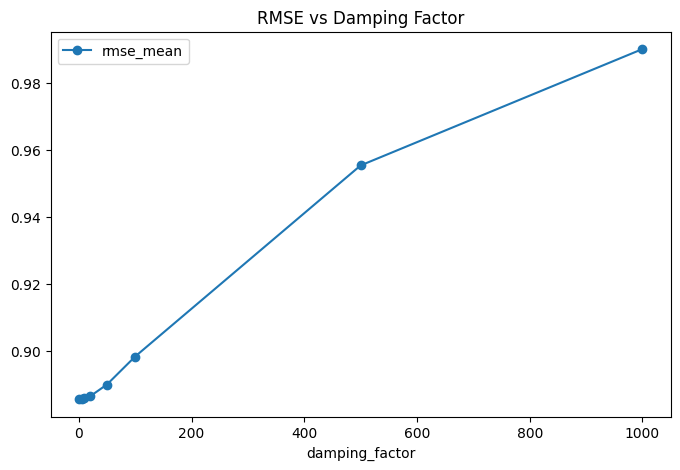

In [11]:
# What was the best damping factor?
'''
Ans:
The best damping factor is 0. This is because it has the lowest RMSE value, as it can be seen in the table above.
The graph below depics the same as well.

'''

rmse_df = rmse_df.sort_values("damping_factor")

rmse_df.plot(
    x="damping_factor",
    y="rmse_mean",
    marker="o",
    figsize=(8,5),
    title="RMSE vs Damping Factor"
)